In [26]:
# ================================================================
# CHUNK 1 — Carga cluster assignments y replicones deduplicados
# ================================================================
import pandas as pd
from pathlib import Path

ROOT = Path(".").resolve()
CLUSTER_ASSIGN = ROOT / "louvain_by_level_from_table_including_isolates" / "cluster_assignments_by_level.tsv"
REPLICONS_TSV  = ROOT / "plasmid_replicons.tsv"

# Carga los archivos clave
assign = pd.read_csv(CLUSTER_ASSIGN, sep="\t", dtype=str)
replicons = pd.read_csv(REPLICONS_TSV, sep="\t", dtype=str)

print(f"[ASSIGN] filas: {assign.shape[0]}, columnas: {assign.columns.tolist()}")
print(f"[REPLICONS] filas: {replicons.shape[0]}, columnas: {replicons.columns.tolist()}")

print("\nEjemplo cluster assignments:")
display(assign.head(5))

print("\nEjemplo de replicones por plásmido:")
display(replicons.head(5))

# Si necesitas tener a mano el path actual:
print(f"Directorio de análisis: {ROOT}")


[ASSIGN] filas: 53515, columnas: ['id', 'level', 'cluster']
[REPLICONS] filas: 53515, columnas: ['plasmid_id', 'replicon_types', 'n_replicons', 'faa', 'size_bp']

Ejemplo cluster assignments:


,id,level,cluster
0,AB011548.2,1,0
1,CP043013.1,1,0
2,CP051825.1,1,0
3,CP051828.1,1,0
4,CP051831.1,1,0



Ejemplo de replicones por plásmido:


,plasmid_id,replicon_types,n_replicons,faa,size_bp
0,AB011548.2,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN
1,AB011549.2,"IncFIA,IncFIB",2,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN
2,AB063523.1,rep_cluster_1526,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN
3,AB244976.1,rep_cluster_1617,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN
4,AB576781.2,IncFII,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN


Directorio de análisis: /home/nacho/HDD16/Nacho/RepliCOOC/derep


In [27]:
# ================================================================
# CHUNK 2 — Carga de taxonomía y unión con cluster assignments y replicones
# ================================================================
import re

# Ruta a resumen taxonómico (raw)
PLSD_SUM  = ROOT.parent / "data" / "raw" / "plsdb_summary.csv"  # asumiendo estructura

# Carga taxonomía
summ_all = pd.read_csv(PLSD_SUM, dtype=str).fillna("")

# Extraemos columnas taxonómicas útiles
tax_cols = [c for c in [
    "NUCCORE_ACC",
    "TAXONOMY.TAXONOMY_genus",
    "TAXONOMY.TAXONOMY_species",
    "TAXONOMY.TAXONOMY_taxon_name"
] if c in summ_all.columns]

tax_all = summ_all[tax_cols].copy()
tax_all = tax_all.rename(columns={"NUCCORE_ACC": "plasmid_id"})

# Normalización de IDs para hacer merge luego
def _normalize_id(pid):
    if pd.isna(pid) or pid == "":
        return ""
    pid_str = str(pid)
    pid_str = pid_str.split("/")[-1]
    for ext in [".fasta", ".fa", ".fna", ".gbk", ".gb", ".csv"]:
        if pid_str.endswith(ext):
            pid_str = pid_str[:-len(ext)]
    return pid_str

tax_all["plasmid_norm"] = tax_all["plasmid_id"].map(_normalize_id)

# Limpiamos nombres de género
def clean_genus_name(g):
    g = re.sub(r"\s*\([^)]*\)\s*$", "", str(g or "")).strip()
    g = re.sub(r"\s+", " ", g)
    return g

if "TAXONOMY.TAXONOMY_genus" in tax_all.columns:
    tax_all["genus"] = tax_all["TAXONOMY.TAXONOMY_genus"].map(clean_genus_name)
else:
    tax_all["genus"] = ""

# Los géneros se unifican junto al id normalizado
tax_all = tax_all[["plasmid_norm", "genus"]].drop_duplicates()

print(f"[TAXONOMY] filas: {len(tax_all):,} | géneros únicos: {tax_all['genus'].nunique()}")

# Unimos con tabla de asignaciones y replicones
# Primero asignamos a cada plásmido su género
assign["id_norm"] = assign["id"].map(_normalize_id)
replicons["plasmid_norm"] = replicons["plasmid_id"].map(_normalize_id)

df = assign.merge(tax_all, left_on="id_norm", right_on="plasmid_norm", how="left")
df = df.merge(replicons, left_on="id_norm", right_on="plasmid_norm", how="left")

print(f"[DATA MASTER] Shape: {df.shape}")
display(df.head(10))


[TAXONOMY] filas: 72,360 | géneros únicos: 954
[DATA MASTER] Shape: (53515, 12)


,id,level,cluster,id_norm,plasmid_norm_x,genus,plasmid_id,replicon_types,n_replicons,faa,size_bp,plasmid_norm_y
0,AB011548.2,1,0,AB011548.2,AB011548.2,Escherichia,AB011548.2,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,AB011548.2
1,CP043013.1,1,0,CP043013.1,CP043013.1,Escherichia,CP043013.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP043013.1
2,CP051825.1,1,0,CP051825.1,CP051825.1,Escherichia,CP051825.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP051825.1
3,CP051828.1,1,0,CP051828.1,CP051828.1,Escherichia,CP051828.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP051828.1
4,CP051831.1,1,0,CP051831.1,CP051831.1,Escherichia,CP051831.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP051831.1
5,CP051834.1,1,0,CP051834.1,CP051834.1,Escherichia,CP051834.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP051834.1
6,CP057376.1,1,0,CP057376.1,CP057376.1,Escherichia,CP057376.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP057376.1
7,CP082661.1,1,0,CP082661.1,CP082661.1,Salmonella,CP082661.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP082661.1
8,CP098939.1,1,0,CP098939.1,CP098939.1,Escherichia,CP098939.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP098939.1
9,CP098946.1,1,0,CP098946.1,CP098946.1,Escherichia,CP098946.1,rep_cluster_2350,1,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,NaN,CP098946.1


In [28]:
# ================================================================
# Conteo de plásmidos por género considerando los clusters multigénero
# ================================================================

# 1) Tabla de miembros por clúster con géneros
members = df[["id_norm", "cluster", "genus"]].drop_duplicates()

# 2) Construir tabla cluster × género: cuáles géneros están en cada cluster
cluster_genus = (members
                 .groupby(["cluster", "genus"])["id_norm"]
                 .nunique()
                 .reset_index()
                 .rename(columns={"id_norm": "n_members_genus"}))

print(f"[CLUSTER GENUS] {cluster_genus.shape} filas (cluster × genus)")
print(cluster_genus.head(8))

# 3) Obtener representante único por clúster (ya deduplicado)
representatives = df.drop_duplicates(subset=["cluster", "id_norm"]) \
                    .groupby("cluster")["id_norm"].first().reset_index() \
                    .rename(columns={"id_norm": "rep_norm"})

# 4) Asociar representantes con géneros de sus clusters
rep_by_genus = representatives.merge(cluster_genus, on="cluster", how="left")

# 5) Contar representantes por género (cada representante puede contar múltiples veces si está en varios géneros)
rep_count_by_genus = (rep_by_genus
                      .groupby("genus")["rep_norm"]
                      .nunique()
                      .sort_values(ascending=False))

print("\n[RESULT] Número de representantes que cubren cada género (contando multi-géneros):")
print(rep_count_by_genus.head(15))

# (Opcional) mostramos top 15 géneros con más representantes
rep_count_by_genus.head(15)


[CLUSTER GENUS] (23551, 3) filas (cluster × genus)
  cluster           genus  n_members_genus
0       0     Escherichia              178
1       0      Klebsiella                2
2       0         Proteus                1
3       0      Raoultella                1
4       0      Salmonella                4
5       0  Staphylococcus                1
6       1      Klebsiella               42
7       1      Raoultella                1

[RESULT] Número de representantes que cubren cada género (contando multi-géneros):
genus
Escherichia            4595
Klebsiella             3483
Enterococcus           1311
Salmonella             1028
Staphylococcus         1005
Enterobacter            956
Acinetobacter           836
Bacillus                801
Citrobacter             642
Lactiplantibacillus     554
Lactococcus             470
Pseudomonas             420
Shigella                311
Streptomyces            284
Aeromonas               237
Name: rep_norm, dtype: int64


genus
Escherichia            4595
Klebsiella             3483
Enterococcus           1311
Salmonella             1028
Staphylococcus         1005
Enterobacter            956
Acinetobacter           836
Bacillus                801
Citrobacter             642
Lactiplantibacillus     554
Lactococcus             470
Pseudomonas             420
Shigella                311
Streptomyces            284
Aeromonas               237
Name: rep_norm, dtype: int64

/tmp/ipykernel_3737/372730004.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=top_genres.index, x=top_genres.values, palette="viridis")


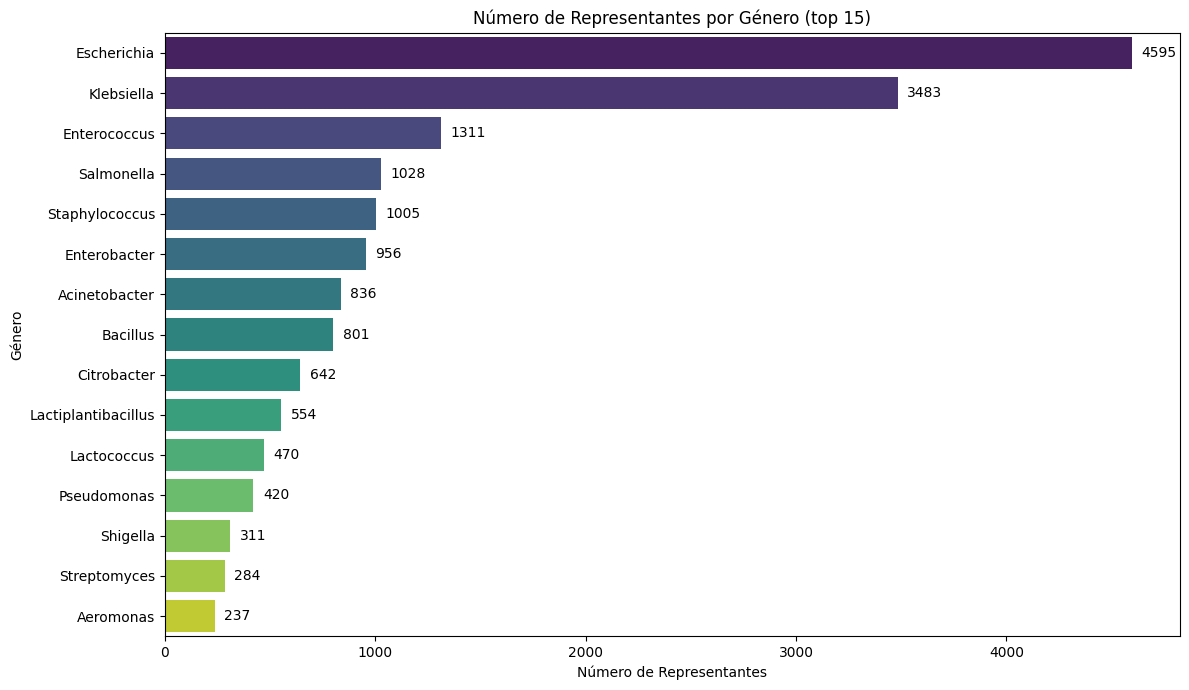

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tomamos top 15 géneros para la figura
top_genres = rep_count_by_genus.head(15)

plt.figure(figsize=(12, 7))
ax = sns.barplot(y=top_genres.index, x=top_genres.values, palette="viridis")

# Añadir etiquetas con los números encima de cada barra
for i, v in enumerate(top_genres.values):
    ax.text(v + max(top_genres.values)*0.01, i, str(v), color='black', va='center')

plt.title("Número de Representantes por Género (top 15)")
plt.xlabel("Número de Representantes")
plt.ylabel("Género")
plt.tight_layout()
plt.show()


In [30]:
# ================================================================
# Construcción tabla rep_norm × géneros con número de replicones
# Adaptado para replicones en cadena separada por comas en columna 'replicon_types'
# ================================================================

# 1) Contar número de replicones diferentes por plásmido (id_norm)
def count_replicons(rep_str):
    if pd.isna(rep_str) or rep_str.strip() == "":
        return 0
    # Contar todos los replicones, sin excluir ninguno
    replicones = [r.strip() for r in rep_str.split(",") if r.strip() != ""]
    return len(replicones)


df["n_replicons"] = df["replicon_types"].map(count_replicons)

# 2) Tabla miembros única: id_norm, cluster, genus
members = df[["id_norm", "cluster", "genus", "n_replicons"]].drop_duplicates()

# 3) Obtener representantes únicos por clúster (uno por cluster)
representatives = df.groupby("cluster")["id_norm"].first().reset_index().rename(columns={"id_norm": "rep_norm"})

# 4) Unir representantes con miembros para expandir info de géneros y replicones
rep_members = representatives.merge(members, on="cluster", how="left")

# 5) Para cada rep_norm y género, tomar el máximo número de replicones entre miembros del género
mob_repXgenus = (rep_members
                 .groupby(["rep_norm", "genus"])["n_replicons"]
                 .max()
                 .reset_index())

print(f"[mob_repXgenus] Dimensiones: {mob_repXgenus.shape}")
print(mob_repXgenus.head(10))


[mob_repXgenus] Dimensiones: (23551, 3)
     rep_norm           genus  n_replicons
0  AB011548.2     Escherichia            8
1  AB011548.2      Klebsiella            7
2  AB011548.2         Proteus            3
3  AB011548.2      Raoultella            4
4  AB011548.2      Salmonella            1
5  AB011548.2  Staphylococcus            6
6  AB063523.1      Klebsiella            7
7  AB063523.1      Raoultella            3
8  AB063523.1      Salmonella            2
9  AB063523.1  Staphylococcus            6


/tmp/ipykernel_3737/413023563.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


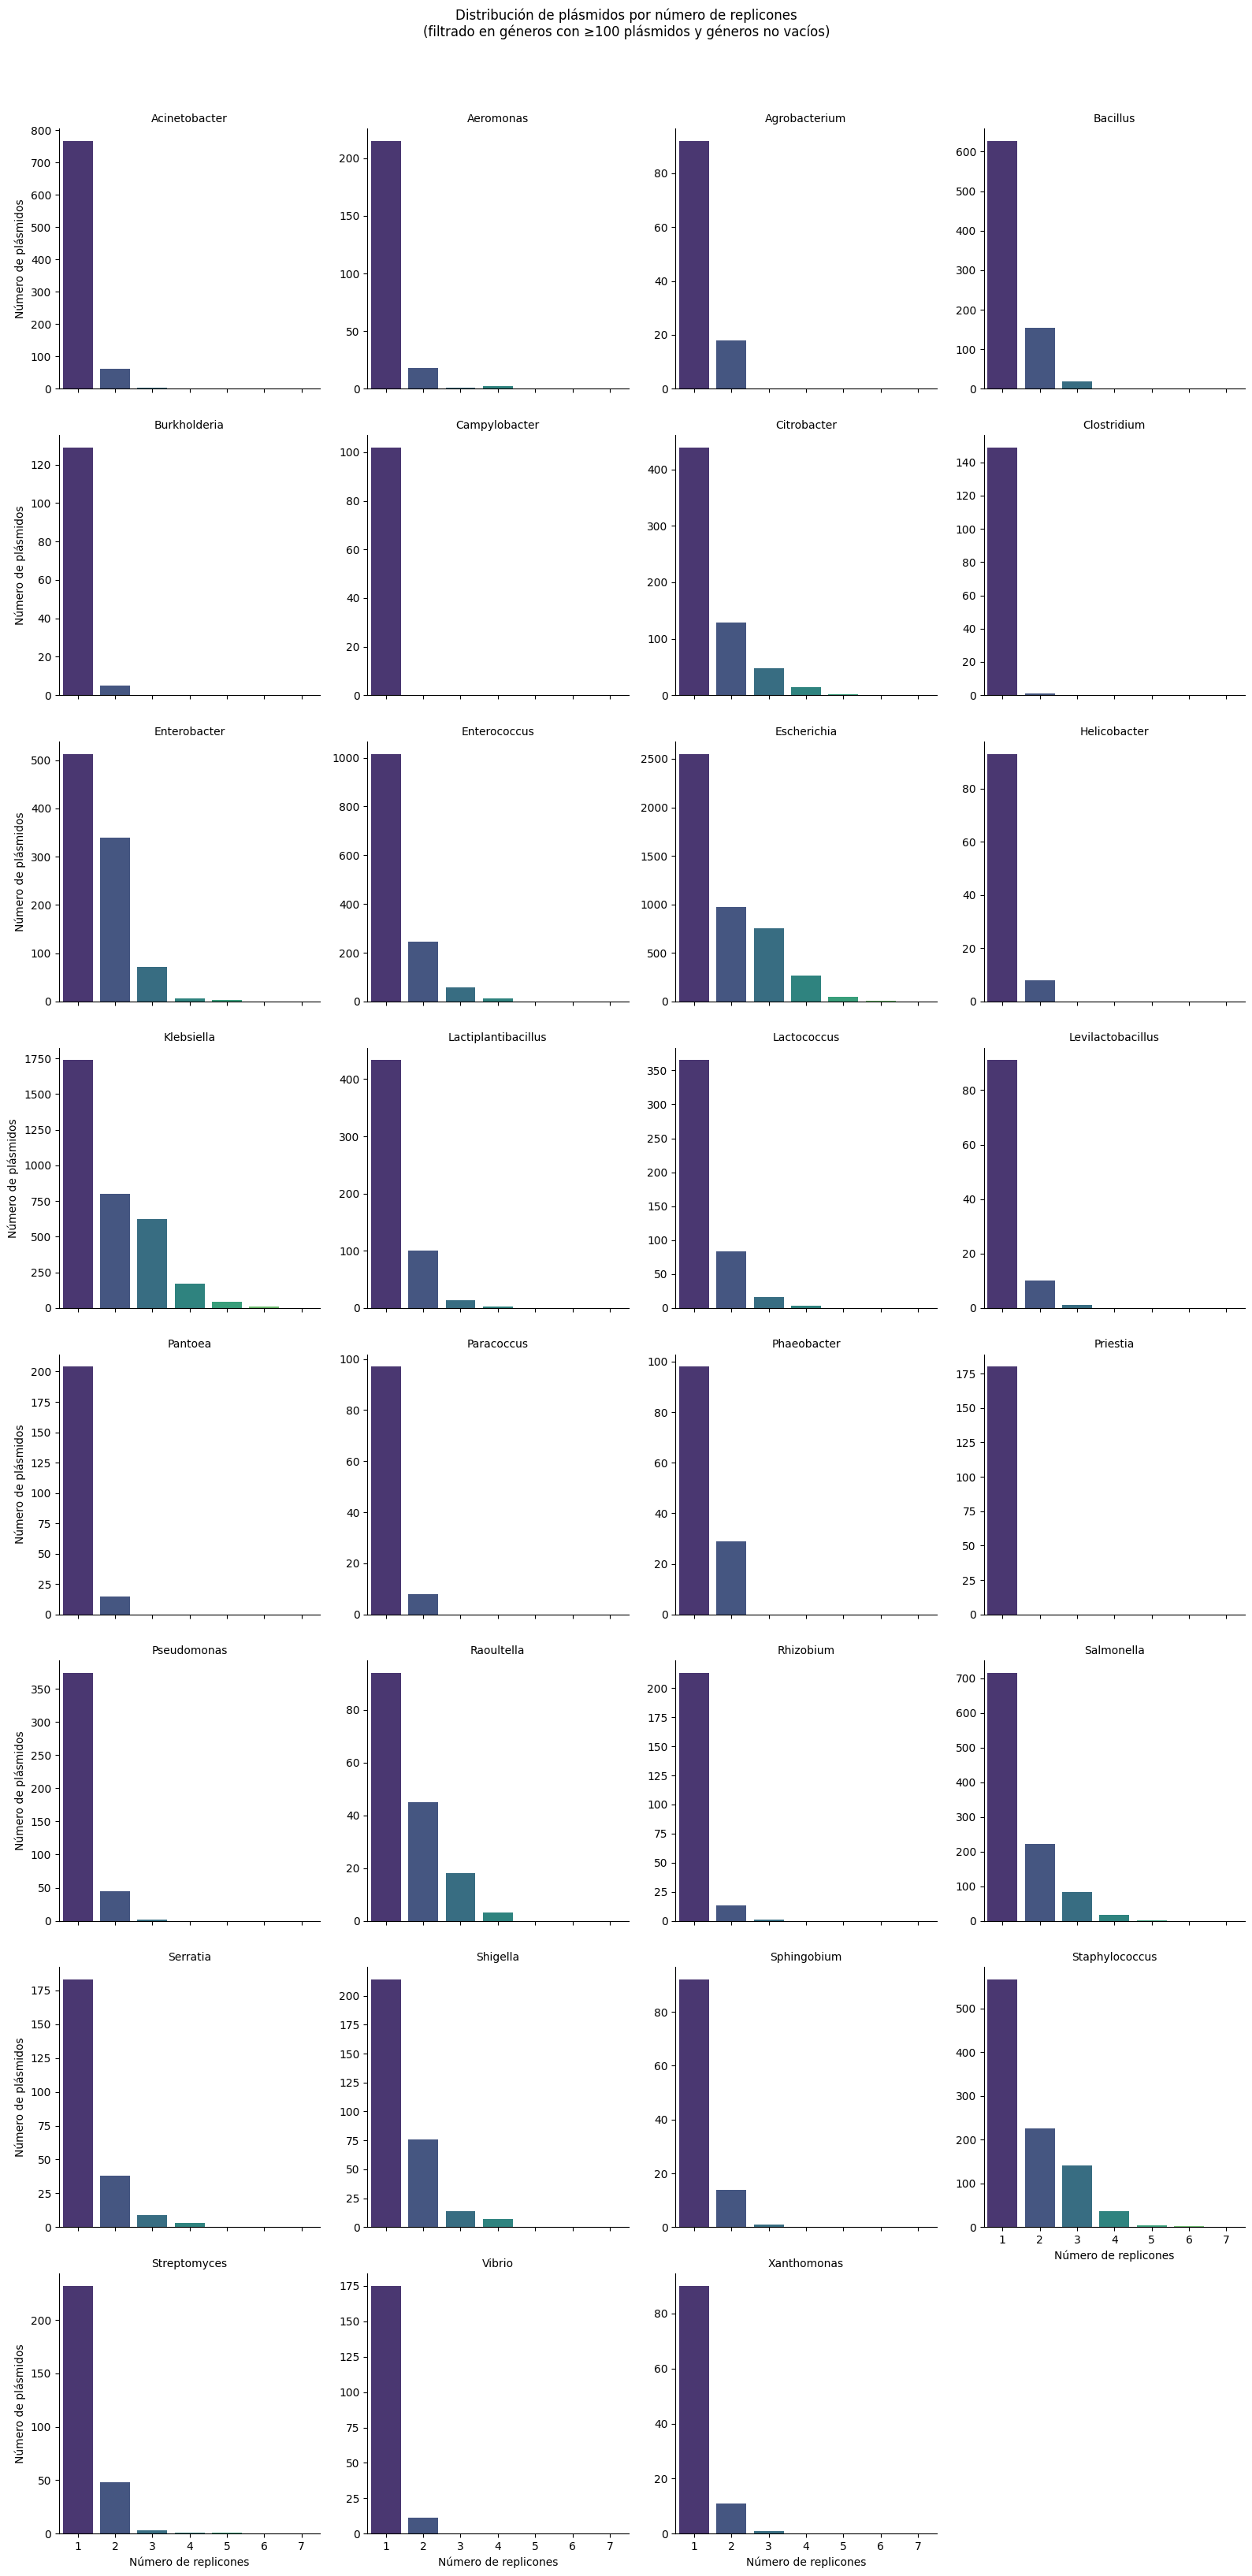

Tipos de columnas tras conversión: [<class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>]
Columnas usadas para calcular proporción (>1 replicones): [2, 3, 4, 5, 6, 7]


/tmp/ipykernel_3737/413023563.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=prop_sorted.index, y=prop_sorted["prop_multi"], palette="magma")


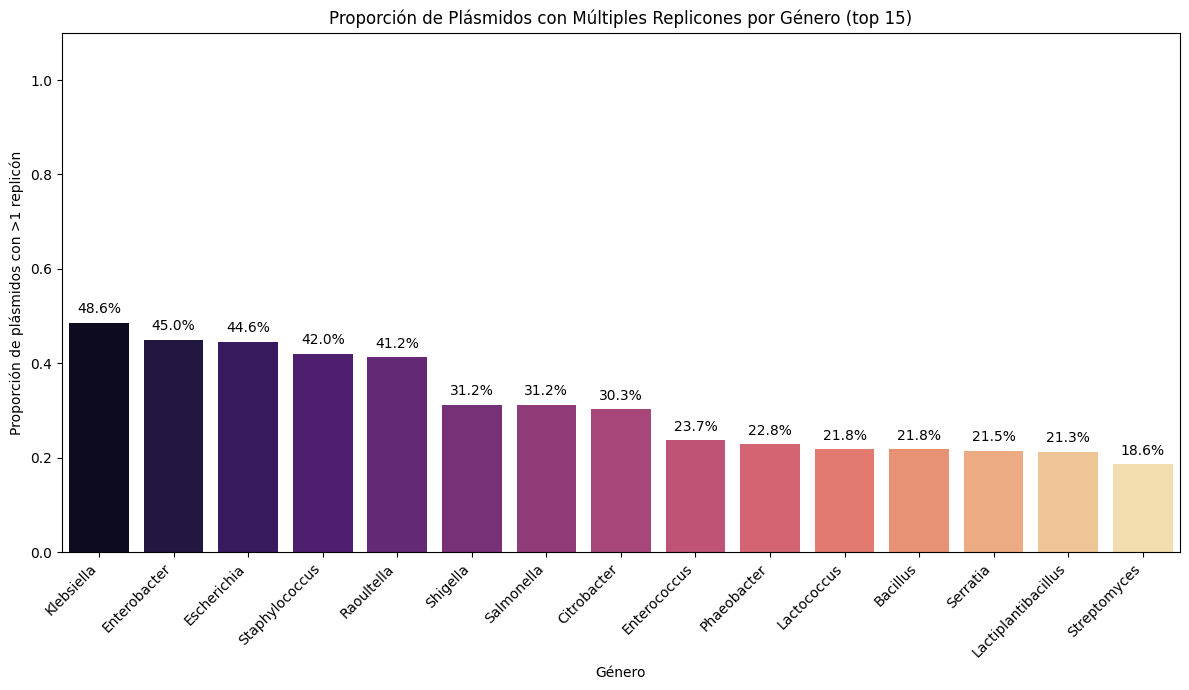

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar géneros vacíos y plásmidos con 0 replicones
mob_repXgenus_filt = mob_repXgenus[mob_repXgenus["genus"].str.strip() != ""]
mob_repXgenus_filt = mob_repXgenus_filt[mob_repXgenus_filt["n_replicons"] > 0].copy()

# Filtrar géneros con al menos 100 plásmidos
plasmids_per_genus = (mob_repXgenus_filt
                      .groupby("genus")["rep_norm"]
                      .nunique()
                      .reset_index()
                      .rename(columns={"rep_norm": "n_plasmids"}))
genera_to_keep = plasmids_per_genus[plasmids_per_genus["n_plasmids"] >= 100]["genus"].tolist()
mob_repXgenus_filt = mob_repXgenus_filt[mob_repXgenus_filt["genus"].isin(genera_to_keep)].copy()

# Tabla para figura faceteada (nº plásmidos con n replicones por género)
count_by_nrep_genus = (mob_repXgenus_filt
                       .groupby(["genus", "n_replicons"])["rep_norm"]
                       .nunique()
                       .reset_index()
                       .rename(columns={"rep_norm": "count"}))

# Figura 1: barras faceteadas
g = sns.catplot(
    data=count_by_nrep_genus,
    x="n_replicons",
    y="count",
    col="genus",
    kind="bar",
    col_wrap=4,
    height=4,
    sharey=False,
    palette="viridis"
)
g.set_axis_labels("Número de replicones", "Número de plásmidos")
g.set_titles("{col_name}")
g.fig.suptitle("Distribución de plásmidos por número de replicones\n(filtrado en géneros con ≥100 plásmidos y géneros no vacíos)", y=1.02)
plt.tight_layout()
plt.show()

# Cálculo de proporción de plásmidos con múltiples replicones (>1 replicón)
proportion_multi_replicon = (
    mob_repXgenus_filt
    .groupby("genus")["n_replicons"]
    .value_counts()
    .unstack(fill_value=0)
)

# Convertir nombres de columnas a enteros para filtrado correcto
try:
    proportion_multi_replicon.columns = proportion_multi_replicon.columns.astype(int)
except Exception as e:
    print("Error al convertir columnas a int:", e)
    print("Tipos actuales:", proportion_multi_replicon.columns)
    raise

# Confirmar el tipo
print("Tipos de columnas tras conversión:", proportion_multi_replicon.columns.map(type).tolist())

# Filtrar columnas > 1 para calcular proporción
cols_gt_1 = [col for col in proportion_multi_replicon.columns if isinstance(col, int) and col > 1]
print("Columnas usadas para calcular proporción (>1 replicones):", cols_gt_1)

proportion_multi_replicon["total"] = proportion_multi_replicon.sum(axis=1)
proportion_multi_replicon["prop_multi"] = proportion_multi_replicon[cols_gt_1].sum(axis=1) / proportion_multi_replicon["total"]

# Ordenar por proporción descendente
proportion_multi_replicon = proportion_multi_replicon[["prop_multi"]].sort_values("prop_multi", ascending=False)

# Figura 2: barras con proporción
prop_sorted = proportion_multi_replicon.head(15)
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=prop_sorted.index, y=prop_sorted["prop_multi"], palette="magma")
for i, v in enumerate(prop_sorted["prop_multi"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontsize=10)
plt.title("Proporción de Plásmidos con Múltiples Replicones por Género (top 15)")
plt.ylabel("Proporción de plásmidos con >1 replicón")
plt.xlabel("Género")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


In [38]:
from pathlib import Path
from Bio import SeqIO
import pandas as pd
import numpy as np

fasta_dir = Path("/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fasta")

lengths = {}

print("Buscando archivos fasta con extensiones comunes...")

# Extensiones comunes para archivos fasta
exts = ["*.fna", "*.fa", "*.fasta"]

files_found = []
for ext in exts:
    files_found.extend(fasta_dir.glob(ext))

print(f"Archivos encontrados: {len(files_found)}")

# Procesar cada archivo encontrado
for fasta_file in files_found:
    plasmid_id = fasta_file.stem
    try:
        record = next(SeqIO.parse(str(fasta_file), "fasta"))
        lengths[plasmid_id] = len(record.seq)
    except Exception as e:
        print(f"Error leyendo {fasta_file}: {e}")
        lengths[plasmid_id] = np.nan

print(f"Longitudes calculadas para {len(lengths)} plásmidos.")

# Asignar al df usando columna 'id' (ajusta si tienes otro nombre)
df["size_bp"] = df["id_norm"].map(lengths)

print(f"Valores de 'size_bp' asignados en df, nulos: {df['size_bp'].isna().sum()}")

print(df[["id", "size_bp"]].head(10))


Buscando archivos fasta con extensiones comunes...
Archivos encontrados: 72556
Longitudes calculadas para 72556 plásmidos.
Valores de 'size_bp' asignados en df, nulos: 0
           id  size_bp
0  AB011548.2     3306
1  CP043013.1     3770
2  CP051825.1     3306
3  CP051828.1     3306
4  CP051831.1     3306
5  CP051834.1     3306
6  CP057376.1     3319
7  CP082661.1    11385
8  CP098939.1     3319
9  CP098946.1     3319


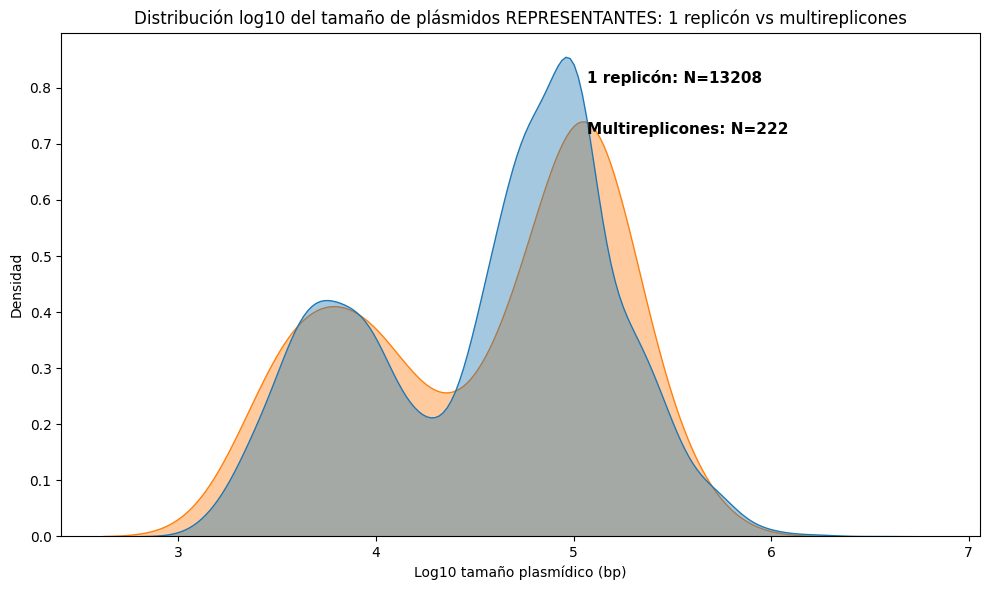

Top 10 géneros por número de representatives: ['Escherichia', 'Klebsiella', 'Enterococcus', 'Salmonella', 'Staphylococcus', 'Enterobacter', 'Acinetobacter', 'Bacillus', 'Citrobacter', 'Lactiplantibacillus']


/home/nacho/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


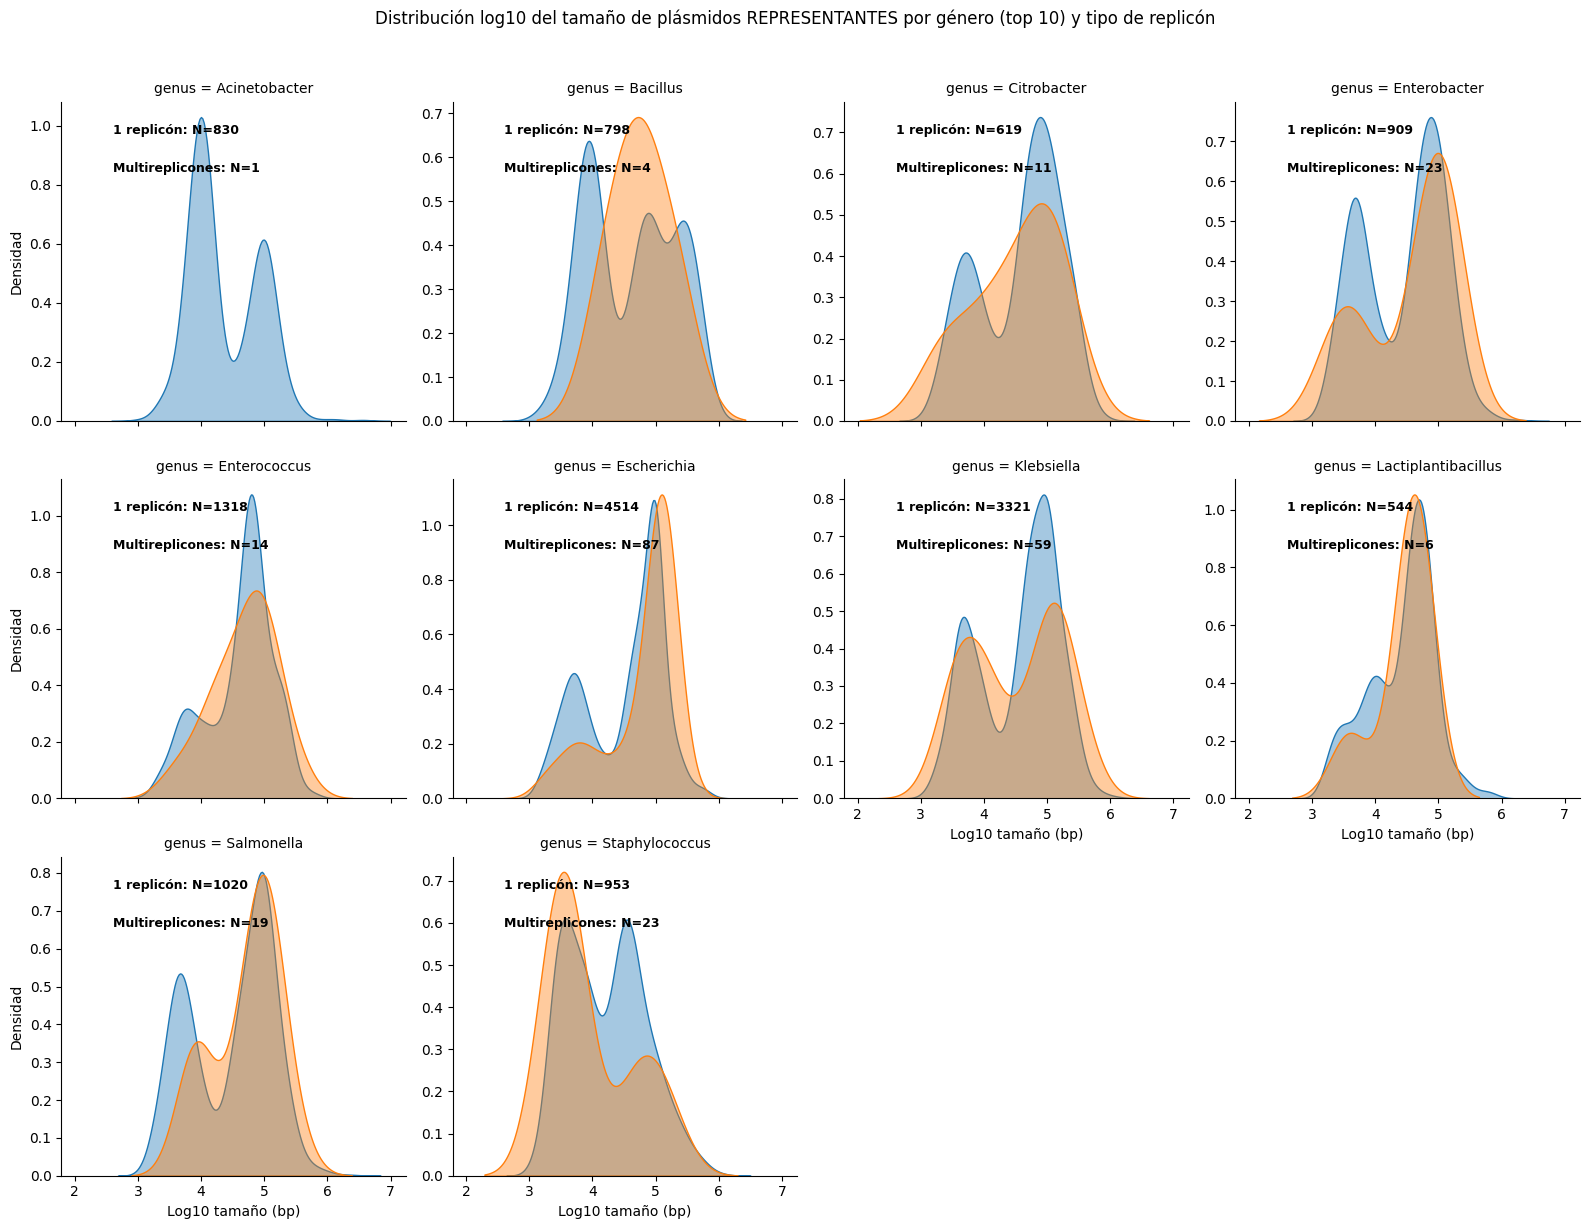

In [62]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Preparación de datos
# =========================

# --- Helpers ---
def split_unique_csv(x: str):
    """Divide por comas, limpia espacios, quita vacíos y mantiene orden sin duplicados."""
    parts = [t.strip() for t in str(x or "").split(",") if t.strip()]
    return list(dict.fromkeys(parts))

def coalesce(*args):
    for a in args:
        if a is not None and not (isinstance(a, float) and np.isnan(a)):
            return a
    return np.nan

# merged ya existe
dfm = merged.copy()

# Asegura tipos básicos
dfm["size_bp"] = pd.to_numeric(dfm["size_bp"], errors="coerce")
# coalesce de n_replicons (usa y si existe, sino x)
dfm["n_replicons"] = [
    coalesce(y, x) for y, x in zip(dfm.get("n_replicons_y"), dfm.get("n_replicons_x"))
]
dfm["n_replicons"] = pd.to_numeric(dfm["n_replicons"], errors="coerce")

# Explota 'genera' a filas: cada representative aparece en todos los géneros listados
dfm["genus_list"] = dfm["genera"].apply(split_unique_csv)
df_exp = dfm.explode("genus_list", ignore_index=True)
df_exp = df_exp.rename(columns={"genus_list": "genus"})

# Limpieza de género
df_exp["genus"] = df_exp["genus"].astype(str).str.strip()
df_exp = df_exp[df_exp["genus"] != ""]

# Filtra tamaños válidos
df_exp = df_exp[(df_exp["size_bp"].notna()) & (df_exp["size_bp"] > 0)]

# (Opcional) filtra a géneros con al menos 100 representatives
GENUS_MIN_N = 100
genus_sizes = df_exp.groupby("genus")["rep_norm"].nunique()
keep_genera = genus_sizes[genus_sizes >= GENUS_MIN_N].index
mob_repXgenus_filt = df_exp[df_exp["genus"].isin(keep_genera)].copy()

# =========================================
# 2) Deduplicación y columnas derivadas
# =========================================

# Para el análisis GLOBAL por representatives, deduplicamos por rep_norm (independiente del género)
df_dedup_global = (
    mob_repXgenus_filt
    .sort_values(["rep_norm"])       # orden estable
    .drop_duplicates(subset="rep_norm", keep="first")
    .copy()
)

# Columna categórica 1 replicón vs multireplicones
df_dedup_global["replicon_category"] = np.where(
    df_dedup_global["n_replicons"] == 1, "1 replicón", "Multireplicones"
)
df_dedup_global["log_size_bp"] = np.log10(df_dedup_global["size_bp"])

# Para el facet por género, deduplicamos dentro de cada género (un representative cuenta una vez por género)
df_dedup_by_genus = (
    mob_repXgenus_filt
    .sort_values(["genus", "rep_norm"])
    .drop_duplicates(subset=["genus", "rep_norm"], keep="first")
    .copy()
)
df_dedup_by_genus["replicon_category"] = np.where(
    df_dedup_by_genus["n_replicons"] == 1, "1 replicón", "Multireplicones"
)
df_dedup_by_genus["log_size_bp"] = np.log10(df_dedup_by_genus["size_bp"])

# =========================================
# 3) Gráfico global KDE
# =========================================

n_counts = df_dedup_global["replicon_category"].value_counts()

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_dedup_global,
    x="log_size_bp",
    hue="replicon_category",
    fill=True, alpha=0.4, common_norm=False, legend=False
)
plt.xlabel("Log10 tamaño plasmídico (bp)")
plt.ylabel("Densidad")
plt.title("Distribución log10 del tamaño de plásmidos REPRESENTANTES: 1 replicón vs multireplicones")

ymax = plt.gca().get_ylim()[1]
xpos = df_dedup_global["log_size_bp"].quantile(0.8) if not df_dedup_global.empty else 3.2
for i, (cat, n) in enumerate(n_counts.items()):
    plt.text(xpos, ymax * (0.9 - 0.1*i), f"{cat}: N={n}", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================
# 4) Facet por top-10 géneros (por N reps únicos)
# =========================================

plasmid_counts = (
    df_dedup_by_genus.groupby("genus")["rep_norm"].nunique().sort_values(ascending=False)
)
top_10_genera = plasmid_counts.head(10).index.tolist()
df_facet = df_dedup_by_genus[df_dedup_by_genus["genus"].isin(top_10_genera)].copy()

print(f"Top 10 géneros por número de representatives: {top_10_genera}")

g = sns.FacetGrid(
    df_facet, col="genus", hue="replicon_category",
    col_wrap=4, height=4, sharex=True, sharey=False, legend_out=False
)
g.map(sns.kdeplot, "log_size_bp", fill=True, alpha=0.4, common_norm=False)

g.set_axis_labels("Log10 tamaño (bp)", "Densidad")
g.fig.suptitle(
    "Distribución log10 del tamaño de plásmidos REPRESENTANTES por género (top 10) y tipo de replicón",
    y=1.02
)

# Añade N por categoría en cada panel
for ax in g.axes.flat:
    # el título del eje es el género
    genus = ax.get_title().replace("genus = ", "")
    df_genus = df_facet[df_facet["genus"] == genus]
    if df_genus.empty:
        continue
    n_by_cat = df_genus.groupby("replicon_category")["rep_norm"].nunique()
    y_max = ax.get_ylim()[1]
    x_min, x_max = ax.get_xlim()
    x_pos = x_min + 0.15*(x_max - x_min)
    for i, (cat, n) in enumerate(n_by_cat.items()):
        ax.text(x_pos, y_max * (0.9 - 0.12*i), f"{cat}: N={n}", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


In [55]:
import pandas as pd

# --- Merge principal ---
merged = df_full.merge(
    df,
    how="left",             # conserva todas las filas de df_full
    left_on="rep_norm",     # clave en df_full
    right_on="id_norm"      # clave en df
)

# --- Opcional: limpiar columnas redundantes ---
# Por ejemplo, eliminar duplicados de genus o n_replicons si los trae repetidos
merged = merged.drop(columns=["plasmid_norm_y"], errors="ignore")

# --- Verificación ---
print(f"Merged shape: {merged.shape}")
print(merged.head(5))


Dataframe completo para análisis de representantes único con info y géneros asociados: 13430 filas


,rep_norm,genus,n_replicons,genera
0,AB011548.2,Escherichia,1,"Escherichia,Salmonella"
1,AB576781.2,Salmonella,1,Salmonella
2,AE016829.2,Klebsiella,3,"Klebsiella,Staphylococcus"
3,AE017195.1,Bacillus,1,Bacillus
4,AF386526.1,Shigella,1,Shigella
